In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import io
import zipfile
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


def download_file(url: str, dest: Path, timeout: int = 45):
    if dest.exists():
        return dest
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    dest.write_bytes(r.content)
    return dest


def print_source(name: str, mode: str):
    print(f"[{name}] data source: {mode}")

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification


def load_churn_data():
    local_csv = DATA_DIR / "telco_churn.csv"
    if local_csv.exists():
        df = pd.read_csv(local_csv)
        if "Churn" in df.columns:
            print_source("Churn", "local csv")
            return df

    try:
        url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
        df = pd.read_csv(url)
        print_source("Churn", "downloaded IBM telco csv")
        return df
    except Exception as e:
        print("Download failed, using synthetic fallback:", e)

    X, y = make_classification(
        n_samples=6000,
        n_features=12,
        n_informative=6,
        n_redundant=2,
        weights=[0.7, 0.3],
        random_state=42,
    )
    df = pd.DataFrame(X, columns=[f"feat_{i}" for i in range(X.shape[1])])
    df["Contract"] = np.where(df["feat_0"] > 0, "Month-to-month", "Two year")
    df["InternetService"] = np.where(df["feat_1"] > 0, "Fiber optic", "DSL")
    df["Churn"] = np.where(y == 1, "Yes", "No")
    print_source("Churn", "synthetic fallback")
    return df


df = load_churn_data()
print("Shape:", df.shape)
df.head()

[Churn] data source: downloaded IBM telco csv
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip()

if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

if "Churn" not in df.columns:
    raise ValueError("Target column 'Churn' missing.")

df["y"] = df["Churn"].map({"Yes": 1, "No": 0})
if df["y"].isna().any():
    raise ValueError("Expected Churn values as Yes/No.")

X = df.drop(columns=["Churn", "y"])
y = df["y"]

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore"))])
prep = ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline(
    steps=[("prep", prep), ("clf", LogisticRegression(max_iter=500, class_weight="balanced", random_state=42))]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

              precision    recall  f1-score   support

           0     0.9022    0.7217    0.8019      1035
           1     0.5043    0.7834    0.6136       374

    accuracy                         0.7381      1409
   macro avg     0.7032    0.7526    0.7078      1409
weighted avg     0.7966    0.7381    0.7519      1409

ROC-AUC: 0.8413


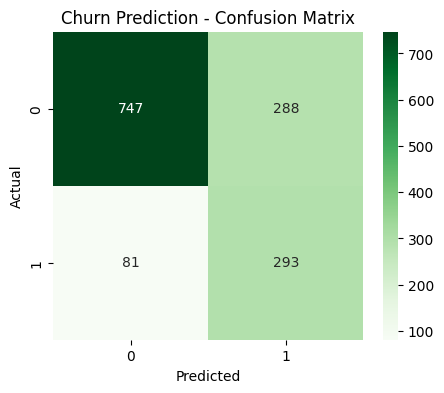

In [4]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Churn Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()